# CardioVision AI — Dataset Audit

In [1]:
import json
from pathlib import Path
import pandas as pd

DATASET_DIR = Path("../data/raw/china_fundus_cimt/Fundus_CIMT_2903 Dataset")
JSON_PATH = DATASET_DIR / "data_info.json"

with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

print("Patients:", len(metadata))
print("First patient ID:", list(metadata.keys())[0])
print("First patient metadata:")
print(metadata[list(metadata.keys())[0]])

Patients: 2903
First patient ID: 2491006
First patient metadata:
{'gender': 0, 'thickness': 0.8, 'label': 0, 'group': 1, 'True_age': 63, 'age': 0.684931506849315, 'right_eye': '2491006_R.png', 'left_eye': '2491006_L.png'}


In [2]:
# CardioVision AI — Dataset Audit

import json
from pathlib import Path
from collections import Counter

# Dataset location
DATASET_DIR = Path("../data/raw/china_fundus_cimt/Fundus_CIMT_2903 Dataset")

# Load metadata
with open(DATASET_DIR / "data_info.json", "r") as f:
    metadata = json.load(f)

print("===== DATASET OVERVIEW =====")
print("Total patients:", len(metadata))

# Extract patient records
records = list(metadata.values())

# Basic distributions
labels = [r["label"] for r in records]
genders = [r["gender"] for r in records]
groups = [r["group"] for r in records]
thickness = [r["thickness"] for r in records]
ages = [r["True_age"] for r in records]

print("\n===== LABEL DISTRIBUTION =====")
print(Counter(labels))

print("\n===== GENDER DISTRIBUTION =====")
print(Counter(genders))

print("\n===== GROUP DISTRIBUTION =====")
print(Counter(groups))

print("\n===== CIMT THICKNESS =====")
print("Minimum:", min(thickness))
print("Maximum:", max(thickness))
print("Mean:", sum(thickness) / len(thickness))

print("\n===== AGE =====")
print("Minimum:", min(ages))
print("Maximum:", max(ages))
print("Mean:", sum(ages) / len(ages))

===== DATASET OVERVIEW =====
Total patients: 2903

===== LABEL DISTRIBUTION =====
Counter({1: 2054, 0: 849})

===== GENDER DISTRIBUTION =====
Counter({1: 1862, 0: 1041})

===== GROUP DISTRIBUTION =====
Counter({1: 2603, 2: 200, 3: 100})

===== CIMT THICKNESS =====
Minimum: 0.5
Maximum: 1.7
Mean: 0.9874371339993034

===== AGE =====
Minimum: 13
Maximum: 86
Mean: 47.94040647605925


In [3]:
# CardioVision AI — Image Integrity Check

print("===== IMAGE INTEGRITY CHECK =====")

missing_left = []
missing_right = []
existing_images = set()

# Find all PNG images in the dataset
all_images = list(DATASET_DIR.rglob("*.png"))

for img in all_images:
    existing_images.add(img.name)

print("Total PNG images found:", len(all_images))

# Check every patient's left and right eye
for patient_id, record in metadata.items():

    left_eye = record["left_eye"]
    right_eye = record["right_eye"]

    if left_eye not in existing_images:
        missing_left.append((patient_id, left_eye))

    if right_eye not in existing_images:
        missing_right.append((patient_id, right_eye))

print("\n===== RESULTS =====")

print("Expected eye images:", len(metadata) * 2)
print("Found eye images:", len(all_images))

print("Missing left-eye images:", len(missing_left))
print("Missing right-eye images:", len(missing_right))

print("\nTotal missing images:",
      len(missing_left) + len(missing_right))

if len(missing_left) == 0 and len(missing_right) == 0:
    print("\n✓ ALL METADATA IMAGES FOUND")
else:
    print("\n⚠ SOME IMAGES ARE MISSING")

    if missing_left:
        print("\nExample missing left images:")
        print(missing_left[:5])

    if missing_right:
        print("\nExample missing right images:")
        print(missing_right[:5])

===== IMAGE INTEGRITY CHECK =====
Total PNG images found: 5806

===== RESULTS =====
Expected eye images: 5806
Found eye images: 5806
Missing left-eye images: 0
Missing right-eye images: 0

Total missing images: 0

✓ ALL METADATA IMAGES FOUND


In [4]:
# CardioVision AI — Master Patient DataFrame

rows = []

for patient_id, record in metadata.items():
    rows.append({
        "patient_id": patient_id,
        "gender": record["gender"],
        "age": record["True_age"],
        "age_normalized": record["age"],
        "cimt_thickness": record["thickness"],
        "label": record["label"],
        "group": record["group"],
        "left_eye": record["left_eye"],
        "right_eye": record["right_eye"],
    })

df = pd.DataFrame(rows)

print("===== MASTER DATAFRAME =====")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 patients:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate patient IDs:")
print(df["patient_id"].duplicated().sum())

===== MASTER DATAFRAME =====
Rows: 2903
Columns: 9

Columns:
['patient_id', 'gender', 'age', 'age_normalized', 'cimt_thickness', 'label', 'group', 'left_eye', 'right_eye']

First 5 patients:


,patient_id,gender,age,age_normalized,cimt_thickness,label,group,left_eye,right_eye
0,2491006,0,63,0.684932,0.8,0,1,2491006_L.png,2491006_R.png
1,3730004,1,61,0.657534,1.2,1,1,3730004_L.png,3730004_R.png
2,3730006,1,64,0.698630,1.2,1,1,3730006_L.png,3730006_R.png
3,4738005,0,53,0.547945,0.7,0,1,4738005_L.png,4738005_R.png
4,6528003,0,66,0.726027,1.2,1,1,6528003_L.png,6528003_R.png



Missing values:
patient_id        0
gender            0
age               0
age_normalized    0
cimt_thickness    0
label             0
group             0
left_eye          0
right_eye         0
dtype: int64

Duplicate patient IDs:
0


In [5]:
# CardioVision AI — Patient-Level Train/Validation/Test Split

from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

# Second split: divide temporary 50/50
# Result = 80% train, 10% validation, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("===== DATASET SPLIT =====")
print("Train patients:", len(train_df))
print("Validation patients:", len(val_df))
print("Test patients:", len(test_df))

print("\n===== LABEL DISTRIBUTION =====")
print("Train:")
print(train_df["label"].value_counts())

print("\nValidation:")
print(val_df["label"].value_counts())

print("\nTest:")
print(test_df["label"].value_counts())

# Verify that no patient appears in multiple splits
train_ids = set(train_df["patient_id"])
val_ids = set(val_df["patient_id"])
test_ids = set(test_df["patient_id"])

print("\n===== LEAKAGE CHECK =====")
print("Train ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

===== DATASET SPLIT =====
Train patients: 2322
Validation patients: 290
Test patients: 291

===== LABEL DISTRIBUTION =====
Train:
label
1    1643
0     679
Name: count, dtype: int64

Validation:
label
1    205
0     85
Name: count, dtype: int64

Test:
label
1    206
0     85
Name: count, dtype: int64

===== LEAKAGE CHECK =====
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [6]:
# CardioVision AI — Build Image Dataset

from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class FundusDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Use left eye image
        image_path = self.image_dir / row["left_eye"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.long)

        return image, label


# Create datasets
train_dataset = FundusDataset(
    train_df,
    DATASET_DIR,
    transform
)

val_dataset = FundusDataset(
    val_df,
    DATASET_DIR,
    transform
)

test_dataset = FundusDataset(
    test_df,
    DATASET_DIR,
    transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Train images: 2322
Validation images: 290
Test images: 291


In [7]:
# Test one image

image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label.item())
print("Image dtype:", image.dtype)

Image tensor shape: torch.Size([3, 224, 224])
Label: 1
Image dtype: torch.float32


In [8]:
# CardioVision AI — DataLoaders + Apple M4 GPU

import torch
from torch.utils.data import DataLoader

# Check device
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# Test one batch
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

# Test M4 GPU
images = images.to(device)

print("Batch device:", images.device)

Using device: mps
Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Batch device: mps:0


In [9]:
# CardioVision AI — EfficientNet-B0 Baseline

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Load pretrained EfficientNet-B0
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Replace final classifier for our 2 classes
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

# Move model to M4 GPU
model = model.to(device)

print("Model:", model.__class__.__name__)
print("Device:", device)
print("Output classes:", 2)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/shimantranjan/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:04<00:00, 5.07MB/s]


Model: EfficientNet
Device: mps
Output classes: 2


In [10]:
# Test model forward pass

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 2])
Labels shape: torch.Size([32])


In [11]:
# CardioVision AI — Training Setup

import torch.nn as nn
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

# Number of epochs
num_epochs = 10

print("Training configuration")
print("----------------------")
print("Device:", device)
print("Optimizer: AdamW")
print("Learning rate: 0.0001")
print("Weight decay: 0.0001")
print("Epochs:", num_epochs)
print("Loss: CrossEntropyLoss")

Training configuration
----------------------
Device: mps
Optimizer: AdamW
Learning rate: 0.0001
Weight decay: 0.0001
Epochs: 10
Loss: CrossEntropyLoss


In [12]:
# CardioVision AI — One Epoch Training Test

model.train()

running_loss = 0.0
correct = 0
total = 0

for batch_idx, (images, labels) in enumerate(train_loader):

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    predictions = outputs.argmax(dim=1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

    # Stop after 10 batches for the first test
    if batch_idx == 9:
        break

accuracy = 100 * correct / total

print("Training test completed")
print("------------------------")
print("Batches:", batch_idx + 1)
print("Loss:", running_loss / (batch_idx + 1))
print("Accuracy:", accuracy, "%")

Training test completed
------------------------
Batches: 10
Loss: 0.6319454550743103
Accuracy: 65.0 %


In [13]:
# CardioVision AI — Class-Weighted Training Setup

import torch
import torch.nn as nn
import torch.optim as optim

# Calculate class weights from training data
class_counts = train_df["label"].value_counts().sort_index()

class_weights = torch.tensor(
    [
        len(train_df) / (2 * class_counts[0]),
        len(train_df) / (2 * class_counts[1])
    ],
    dtype=torch.float32
).to(device)

print("Class counts:")
print(class_counts)

print("\nClass weights:", class_weights)

# Weighted loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print("\nTraining setup ready.")

Class counts:
label
0     679
1    1643
Name: count, dtype: int64

Class weights: tensor([1.7099, 0.7066], device='mps:0')

Training setup ready.


In [14]:
# CardioVision AI — Baseline Training

from sklearn.metrics import roc_auc_score
import numpy as np
from pathlib import Path
import torch

num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_aucs = []

best_val_auc = 0.0

# Create checkpoint directory
checkpoint_dir = Path("../models")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

for epoch in range(num_epochs):

    # =========================
    # TRAIN
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            probabilities = torch.softmax(outputs, dim=1)[:, 1]

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    val_auc = roc_auc_score(all_labels, all_probs)

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_aucs.append(val_auc)

    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_auc > best_val_auc:

        best_val_auc = val_auc

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_auc": val_auc,
            },
            checkpoint_dir / "efficientnet_b0_best.pt"
        )

        best_marker = " ⭐ BEST"

    else:
        best_marker = ""

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f} "
        f"| Val ROC-AUC: {val_auc:.4f}"
        f"{best_marker}"
    )

print("\nTraining complete.")
print(f"Best Validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best model saved to: {checkpoint_dir / 'efficientnet_b0_best.pt'}")

Epoch [1/10] | Train Loss: 0.5868 | Train Acc: 0.7227 | Val Loss: 0.4860 | Val Acc: 0.7897 | Val ROC-AUC: 0.8587 ⭐ BEST
Epoch [2/10] | Train Loss: 0.4699 | Train Acc: 0.7817 | Val Loss: 0.4982 | Val Acc: 0.7586 | Val ROC-AUC: 0.8370
Epoch [3/10] | Train Loss: 0.3698 | Train Acc: 0.8368 | Val Loss: 0.5678 | Val Acc: 0.7103 | Val ROC-AUC: 0.7980
Epoch [4/10] | Train Loss: 0.2768 | Train Acc: 0.8846 | Val Loss: 0.6103 | Val Acc: 0.7448 | Val ROC-AUC: 0.8212
Epoch [5/10] | Train Loss: 0.1949 | Train Acc: 0.9251 | Val Loss: 0.7932 | Val Acc: 0.7655 | Val ROC-AUC: 0.7995
Epoch [6/10] | Train Loss: 0.1385 | Train Acc: 0.9475 | Val Loss: 0.8562 | Val Acc: 0.7517 | Val ROC-AUC: 0.8107
Epoch [7/10] | Train Loss: 0.1123 | Train Acc: 0.9608 | Val Loss: 0.9377 | Val Acc: 0.7310 | Val ROC-AUC: 0.8004
Epoch [8/10] | Train Loss: 0.0834 | Train Acc: 0.9703 | Val Loss: 0.9657 | Val Acc: 0.7724 | Val ROC-AUC: 0.8146
Epoch [9/10] | Train Loss: 0.0705 | Train Acc: 0.9793 | Val Loss: 0.8069 | Val Acc: 0.748

In [15]:
# CardioVision AI — Final Test Evaluation

import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load BEST validation model
checkpoint = torch.load(
    "../models/efficientnet_b0_best.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]

        all_labels.extend(labels.numpy())
        all_probs.extend(probabilities.cpu().numpy())

# Convert to numpy
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Classification threshold
all_predictions = (all_probs >= 0.5).astype(int)

# Metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, zero_division=0)
recall = recall_score(all_labels, all_predictions, zero_division=0)
f1 = f1_score(all_labels, all_predictions, zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs)

cm = confusion_matrix(all_labels, all_predictions)

print("========================================")
print("CARDIOVISION AI — TEST RESULTS")
print("========================================")

print(f"Test samples: {len(all_labels)}")
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1 Score:     {f1:.4f}")
print(f"ROC-AUC:      {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Normal", "Abnormal"],
        zero_division=0
    )
)

CARDIOVISION AI — TEST RESULTS
Test samples: 291
Accuracy:     0.7698
Precision:    0.8798
Recall:       0.7816
F1 Score:     0.8278
ROC-AUC:      0.8404

Confusion Matrix:
[[ 63  22]
 [ 45 161]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.58      0.74      0.65        85
    Abnormal       0.88      0.78      0.83       206

    accuracy                           0.77       291
   macro avg       0.73      0.76      0.74       291
weighted avg       0.79      0.77      0.78       291



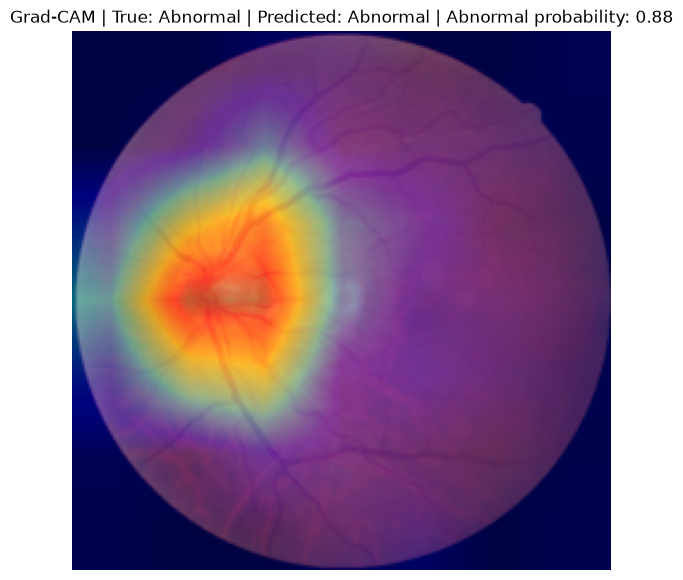

In [16]:
# CardioVision AI — Grad-CAM Explainability

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Make sure best model is loaded
checkpoint = torch.load(
    "../models/efficientnet_b0_best.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

# EfficientNet-B0 final convolutional feature layer
target_layer = model.features[-1]

activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# Take one test image
images, labels = next(iter(test_loader))

image = images[0:1].to(device)
label = labels[0].item()

# Forward pass
output = model(image)
probability = torch.softmax(output, dim=1)[0, 1]

# Backpropagate abnormal-class score
model.zero_grad()
output[0, 1].backward()

# Get activations and gradients
activation = activations[0]
gradient = gradients[0]

# Global average pooling of gradients
weights = gradient.mean(dim=(2, 3), keepdim=True)

# Weighted feature maps
cam = (weights * activation).sum(dim=1).squeeze()

# ReLU
cam = torch.relu(cam)

# Normalize
cam = cam.detach().cpu().numpy()

if cam.max() > 0:
    cam = cam / cam.max()

# Convert original tensor back to image
img = image[0].detach().cpu().permute(1, 2, 0).numpy()

# Normalize for display
img = (img - img.min()) / (img.max() - img.min())

# Resize CAM to image size
from PIL import Image

cam_image = Image.fromarray(
    np.uint8(cam * 255)
).resize(
    (img.shape[1], img.shape[0]),
    Image.BILINEAR
)

cam = np.array(cam_image) / 255.0

# Display
plt.figure(figsize=(7, 7))

plt.imshow(img)
plt.imshow(cam, cmap="jet", alpha=0.45)

plt.axis("off")

prediction = "Abnormal" if probability.item() >= 0.5 else "Normal"

plt.title(
    f"Grad-CAM | True: {'Abnormal' if label == 1 else 'Normal'} "
    f"| Predicted: {prediction} "
    f"| Abnormal probability: {probability.item():.2f}"
)

plt.show()

# Remove hooks
forward_handle.remove()
backward_handle.remove()

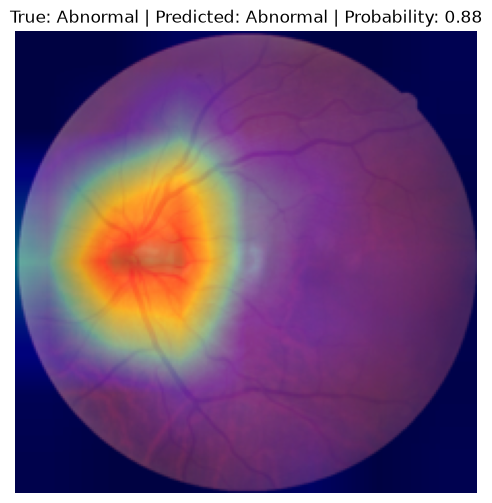

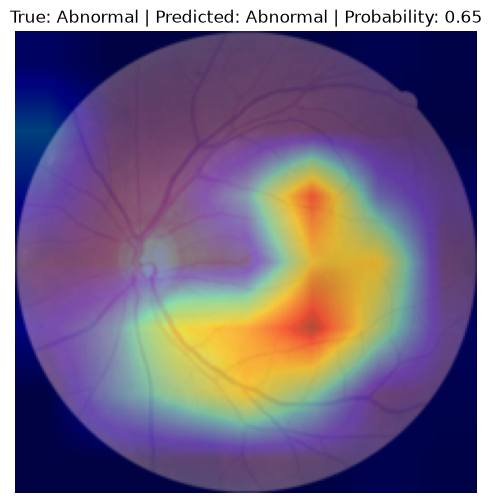

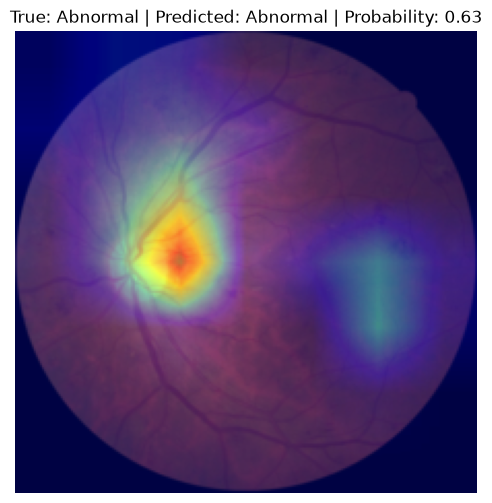

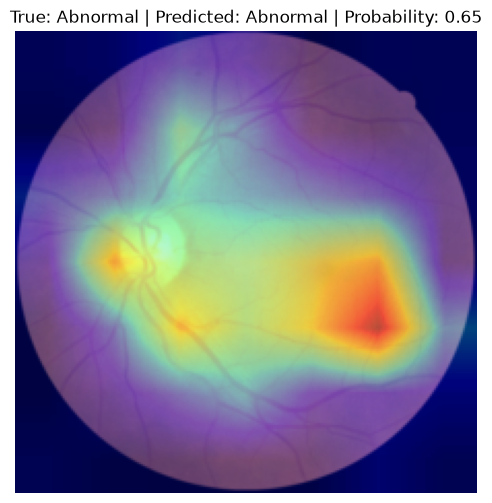

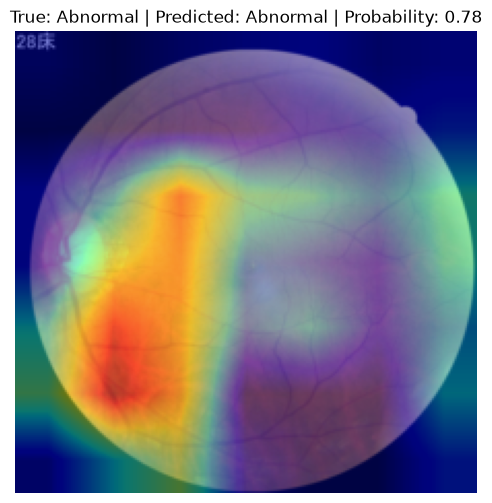

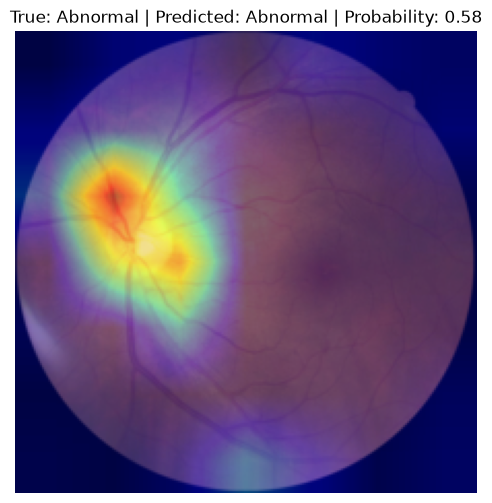

In [17]:
# CardioVision AI — Grad-CAM Multiple Test Examples

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def generate_gradcam(model, image, target_class=1):

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.features[-1]

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()

    output = model(image)
    probability = torch.softmax(output, dim=1)[0, 1]

    output[0, target_class].backward()

    activation = activations[0]
    gradient = gradients[0]

    weights = gradient.mean(dim=(2, 3), keepdim=True)

    cam = (weights * activation).sum(dim=1).squeeze()
    cam = torch.relu(cam)

    cam = cam.detach().cpu().numpy()

    if cam.max() > 0:
        cam = cam / cam.max()

    # Convert image for visualization
    img = image[0].detach().cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    cam = np.array(
        Image.fromarray(np.uint8(cam * 255))
        .resize((img.shape[1], img.shape[0]), Image.BILINEAR)
    ) / 255.0

    fh.remove()
    bh.remove()

    return img, cam, probability.item()


# Take several test images
test_images, test_labels = next(iter(test_loader))

for i in range(min(6, len(test_images))):

    image = test_images[i:i+1].to(device)
    true_label = test_labels[i].item()

    img, cam, probability = generate_gradcam(
        model,
        image,
        target_class=1
    )

    prediction = 1 if probability >= 0.5 else 0

    plt.figure(figsize=(6, 6))

    plt.imshow(img)
    plt.imshow(cam, cmap="jet", alpha=0.45)

    plt.axis("off")

    plt.title(
        f"True: {'Abnormal' if true_label else 'Normal'} | "
        f"Predicted: {'Abnormal' if prediction else 'Normal'} | "
        f"Probability: {probability:.2f}"
    )

    plt.show()